# Import Libraries

In [2]:
import sys
!{sys.executable} -m pip install --quiet catboost xgboost lightgbm

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modern gradient-boosting libraries (added on top of the starter's models).
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Data Processing

### Loading the data

In [5]:


train_df = pd.read_csv("../data/VFL_2026_TRAIN_SET.csv")
test_df  = pd.read_csv("../data/VFL_2026_TEST_SET.csv")

# Key cleanup kept as a harmless safety net (strip any stray non-digits from ENCOUNTER_KEY).
# for _df in (train_df, test_df):
#     _df["ENCOUNTER_KEY"] = _df["ENCOUNTER_KEY"].astype(str).str.replace(r"\D", "", regex=True)

print("train:", train_df.shape, "| test:", test_df.shape)

train: (100000, 46) | test: (15000, 45)


### Exploring data

In [6]:
# Which column is in train but not test? (the target) and where are the missing values?
extra_cols = set(train_df.columns) - set(test_df.columns)
print("EXTRA COLUMN ON TRAIN (the thing we predict):", extra_cols)
print("\nMissing values (train):")
miss = train_df.isna().mean()
print((miss[miss > 0] * 100).round(2))

EXTRA COLUMN ON TRAIN (the thing we predict): {'ADMIT_LOS'}

Missing values (train):
PROCEDURE_SUBCAT_DESC    32.07
PROCEDURE_LONG_DESC      32.07
dtype: float64


### Distribution of ADMIT_LOS

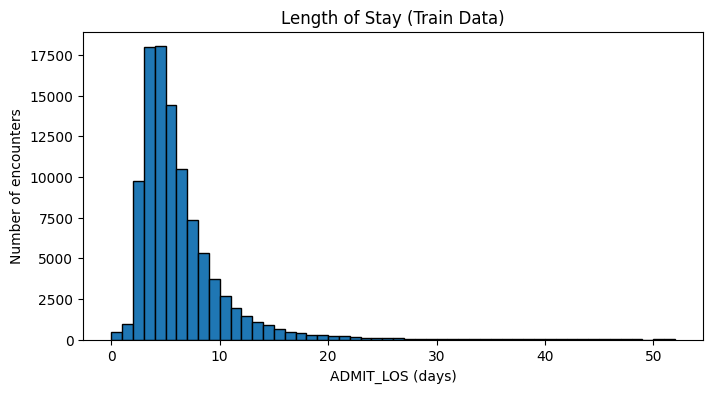

In [7]:
plt.figure(figsize=(8,4))
plt.hist(train_df["ADMIT_LOS"], bins=range(0, int(train_df["ADMIT_LOS"].max())+2), edgecolor="black")
plt.title("Length of Stay (Train Data)")
plt.xlabel("ADMIT_LOS (days)"); plt.ylabel("Number of encounters")
plt.show()

The length of stay is right-skewed

### Correlation with ADMIT_LOS

In [8]:
def strip_num(x):
    return pd.to_numeric(x.astype(str).str.strip(), errors="coerce")

quick = train_df[["ICU_DAYS","ORDER_TOTAL_CHARGES","PATIENT_AGE","OPERATION_COUNT",
                  "NUM_VISITS","ADMIT_MTH","MS_DRG_CODE","ICD9_TARGET"]].copy()
quick["DRG_APR_SEVERITY"] = strip_num(train_df["DRG_APR_SEVERITY"])
quick["NUM_CHRONIC_COND"] = strip_num(train_df["NUM_CHRONIC_COND"])
quick["ADMIT_LOS"]        = strip_num(train_df["ADMIT_LOS"])
print("Correlation with ADMIT_LOS")
print(quick.corr()["ADMIT_LOS"].drop("ADMIT_LOS").sort_values(ascending=False))

Correlation with ADMIT_LOS
ICU_DAYS               0.592659
ORDER_TOTAL_CHARGES    0.523058
DRG_APR_SEVERITY       0.433559
OPERATION_COUNT        0.200184
PATIENT_AGE            0.117486
NUM_CHRONIC_COND       0.116715
ADMIT_MTH             -0.001183
NUM_VISITS            -0.003407
ICD9_TARGET           -0.005728
MS_DRG_CODE           -0.025334
Name: ADMIT_LOS, dtype: float64


Icu and Order total charges has the highest correlation.

## Clean & select features

Strip padded numerics, keep the feature set that cross-validated best. 

In [9]:
target = "ADMIT_LOS"

numeric = ["ICU_DAYS","ORDER_TOTAL_CHARGES","PATIENT_AGE","OPERATION_COUNT","NUM_VISITS",
           "ADMIT_MTH","MS_DRG_CODE","ZIP","X","Y","DX_CODE","ICD9_TARGET",
           "ORDER_SET_USED","DIAGNOSIS_ICD_CODE"]
numeric_text = ["NUM_CHRONIC_COND","DRG_APR_SEVERITY","PROCEDURE_SUBCAT_CODE"]
categorical = ["DOCTOR","DEPARTMENT","DISCHARGED_TO","STANDARD_ORDERS_USED","DISCH_NURSE_ID",
               "GENDER","STATECODE","REGION","RACE_CD","DIAGNOSIS_GROUP","DRG_APR_CODE",
               "DIAGNOSIS_SUBCAT_CODE","PROCEDURE_ICD_CODE","HOSPITAL"]

def build_features(df):
    X = pd.DataFrame(index=df.index)
    for c in numeric:      X[c] = pd.to_numeric(df[c], errors="coerce")
    for c in numeric_text: X[c] = strip_num(df[c])
    for c in categorical:  X[c] = df[c].astype(str).str.strip()
    return X

X_all = build_features(train_df)
X_sub = build_features(test_df)
y_all = train_df[target].astype(float)

num_cols, cat_cols = numeric + numeric_text, categorical
print(f"{X_all.shape[1]} features: {len(num_cols)} numeric + {len(cat_cols)} categorical")

31 features: 17 numeric + 14 categorical


### Encoding and partitioning data

Same as the template: one-hot encode the categoricals, align train/test columns, fill gaps with the median, then make a 70/21/9 train / validation / holdout split.

In [10]:
X_all_enc = pd.get_dummies(X_all, columns=cat_cols, drop_first=True)
X_sub_enc = pd.get_dummies(X_sub, columns=cat_cols, drop_first=True)
X_sub_enc = X_sub_enc.reindex(columns=X_all_enc.columns, fill_value=0)

# Sanitize column names: category values like "ROUTINE DSCHG, HOME" create dummy columns with
# commas/brackets that LightGBM rejects. Replace any non-alphanumeric character with an underscore.
clean_cols = X_all_enc.columns.str.replace(r"[^0-9A-Za-z_]", "_", regex=True)
X_all_enc.columns = clean_cols
X_sub_enc.columns = clean_cols

med = X_all_enc.median(numeric_only=True)
X_all_enc = X_all_enc.fillna(med)
X_sub_enc = X_sub_enc.fillna(med)

bool_cols = X_all_enc.select_dtypes(include="bool").columns
X_all_enc[bool_cols] = X_all_enc[bool_cols].astype(int)
X_sub_enc[bool_cols] = X_sub_enc[bool_cols].astype(int)
print(f"After one-hot encoding: {X_all_enc.shape[1]} feature columns")

X_train, X_temp, y_train, y_temp = train_test_split(X_all_enc, y_all, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.30, random_state=42)
print(f"train {X_train.shape[0]:,} | val {X_val.shape[0]:,} | holdout {X_test.shape[0]:,}")

After one-hot encoding: 393 feature columns
train 70,000 | val 21,000 | holdout 9,000


# Model Building

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

def make_models():
    return {
        "Linear":            LinearRegression(),
        "Random Forest":     RandomForestRegressor(n_estimators=120, max_depth=20,
                                                   n_jobs=-1, random_state=42),
        "Gradient Boosting": HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                 max_leaf_nodes=63, min_samples_leaf=40, l2_regularization=2.0,
                                 early_stopping=True, validation_fraction=0.1,
                                 n_iter_no_change=40, random_state=7),
        "XGBoost":           xgb.XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=7,
                                 min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                                 reg_lambda=2.0, random_state=7, verbosity=0),
        "LightGBM":          lgb.LGBMRegressor(n_estimators=1200, learning_rate=0.03, num_leaves=63,
                                 min_child_samples=40, subsample=0.8, subsample_freq=1,
                                 colsample_bytree=0.8, reg_lambda=2.0, random_state=7, verbose=-1),
        "CatBoost":          CatBoostRegressor(iterations=1500, learning_rate=0.03, depth=8,
                                 l2_leaf_reg=3.0, random_seed=7, verbose=0),
    }

models = make_models()
sk_predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    sk_predictions[name] = np.clip(model.predict(X_val), 0, None)
    print(f"trained (scikit-learn): {name}")

trained (scikit-learn): Linear
trained (scikit-learn): Random Forest
trained (scikit-learn): Gradient Boosting
trained (scikit-learn): XGBoost
trained (scikit-learn): LightGBM
trained (scikit-learn): CatBoost


Tookatleast3m43s

## Using SAS Viya

In [15]:
sas_predictions = {}
from sasviya.ml.linear_model import LinearRegression as Linear
from sasviya.ml.tree import ForestRegressor as Forest, GradientBoostingRegressor as GB
sas_models = {
    # "Linear":            Linear(),
    # "Ridge":             Ridge(alpha=1.0),
    # "Lasso":             Lasso(),
    "Random Forest":     Forest(n_estimators=120, max_depth=20, random_state=42),
    "Gradient Boosting": GB(n_estimators=600, max_depth=6, learning_rate=0.05,
                            subsample=0.8, random_state=7),
    "Gradient Boosting Deep": GB(n_estimators=1000, max_depth=8, learning_rate=0.03,
                                    subsample=0.8, random_state=7),
    "Gradient Boosting Fine": GB(n_estimators=1500, max_depth=5, learning_rate=0.03,
                                    subsample=0.8, random_state=7),
}
for name, model in sas_models.items():
    model.fit(X_train, y_train)
    sas_predictions[name] = np.clip(model.predict(X_val), 0, None)
    print(f"trained (SAS Viya): {name}")

trained (SAS Viya): Random Forest
trained (SAS Viya): Gradient Boosting
trained (SAS Viya): Gradient Boosting Deep
trained (SAS Viya): Gradient Boosting Fine


# Model Eval

Combine both frameworks and rank every model on the validation set by RMSE

In [16]:
all_predictions = {}
for name, p in sk_predictions.items():  all_predictions[f"{name} (scikit-learn)"] = p
for name, p in sas_predictions.items(): all_predictions[f"{name} (SAS Viya)"] = p

rows = []
for label, p in all_predictions.items():
    rows.append({"Model": label,
                 "RMSE": round(mean_squared_error(y_val, p) ** 0.5, 4),
                 "MAE":  round(mean_absolute_error(y_val, p), 4),
                 "R2":   round(r2_score(y_val, p), 4)})
results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
print("Validation-set comparison (lower RMSE is better):")
print(results.to_string(index=False))

Validation-set comparison (lower RMSE is better):
                            Model   RMSE    MAE     R2
          CatBoost (scikit-learn) 2.0201 1.3338 0.7644
 Gradient Boosting (scikit-learn) 2.0484 1.3474 0.7577
           XGBoost (scikit-learn) 2.0551 1.3516 0.7561
          LightGBM (scikit-learn) 2.0663 1.3560 0.7534
Gradient Boosting Fine (SAS Viya) 2.1121 1.3713 0.7424
     Gradient Boosting (SAS Viya) 2.1184 1.3750 0.7409
Gradient Boosting Deep (SAS Viya) 2.1383 1.3852 0.7360
     Random Forest (scikit-learn) 2.1631 1.4049 0.7298
            Linear (scikit-learn) 2.5120 1.6480 0.6356
         Random Forest (SAS Viya) 2.7928 1.7507 0.5496


### Diagnostic plots for the best model

Best on validation: CatBoost (scikit-learn) (RMSE 2.0201)


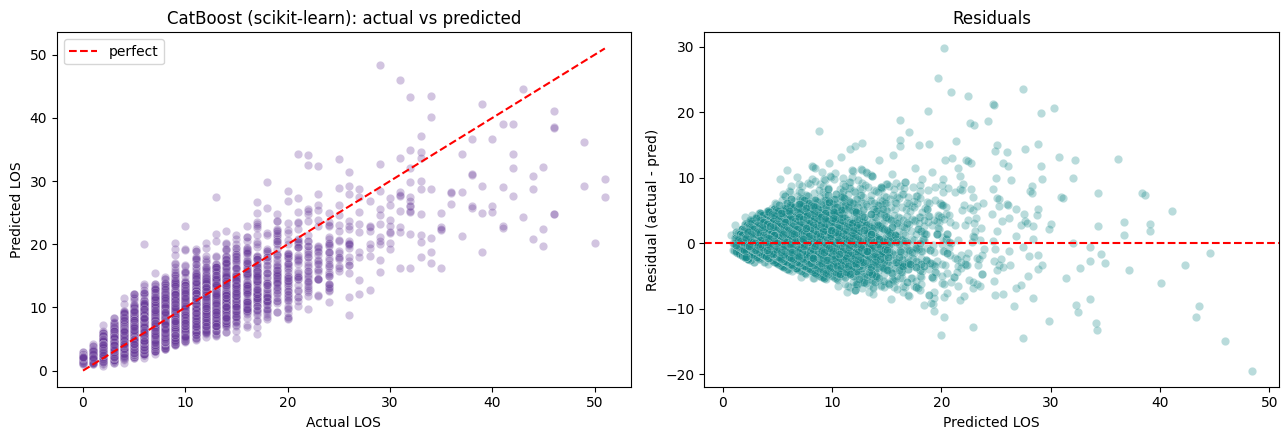

In [17]:
best_label = results.iloc[0]["Model"]
y_pred_val = all_predictions[best_label]
print(f"Best on validation: {best_label} (RMSE {results.iloc[0]['RMSE']})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(y_val, y_pred_val, alpha=0.3, color="#6A3D9A", edgecolors="white", linewidths=0.3)
lims = [y_val.min(), y_val.max()]
ax[0].plot(lims, lims, "--", color="red", label="perfect")
ax[0].set_xlabel("Actual LOS"); ax[0].set_ylabel("Predicted LOS")
ax[0].set_title(f"{best_label}: actual vs predicted"); ax[0].legend()

resid = y_val - y_pred_val
ax[1].scatter(y_pred_val, resid, alpha=0.3, color="#178A8A", edgecolors="white", linewidths=0.3)
ax[1].axhline(0, color="red", ls="--")
ax[1].set_xlabel("Predicted LOS"); ax[1].set_ylabel("Residual (actual - pred)")
ax[1].set_title("Residuals")
plt.tight_layout(); plt.show()

### Overfitting check on the untouched holdout

In [18]:
pure = best_label.replace(" (scikit-learn)", "").replace(" (SAS Viya)", "")
best_model = (sas_models if best_label.endswith("(SAS Viya)") else models)[pure]
y_hold = np.clip(best_model.predict(X_test), 0, None)
print(f"{best_label} holdout RMSE: {mean_squared_error(y_test, y_hold) ** 0.5:.4f}")
print(f"{best_label} holdout MAE : {mean_absolute_error(y_test, y_hold):.4f}")
print(f"{best_label} holdout R2  : {r2_score(y_test, y_hold):.4f}")

CatBoost (scikit-learn) holdout RMSE: 1.9584
CatBoost (scikit-learn) holdout MAE : 1.3292
CatBoost (scikit-learn) holdout R2  : 0.7727


# Refit on all data & create the submission
The evaluation table shows the strongest learners. Instead of shipping just one, we **blend the top
gradient boosters** - averaging models that make different mistakes lowers RMSE further. We compute
non-negative blend weights on the validation predictions (so no model gets a negative weight), then
refit those models on **all** labelled data and apply the same weights to the test set.

As before, we submit the **continuous (unrounded)** prediction: RMSE is minimised by the conditional
mean, so rounding to whole days would *increase* the error.

In [ ]:
from scipy.optimize import nnls

# Blend the three boosting members that topped the table.
blend_members = ["CatBoost", "XGBoost", "Gradient Boosting"]
V = np.column_stack([sk_predictions[m] for m in blend_members])
w, _ = nnls(V, y_val.values)
w = w / w.sum() if w.sum() > 0 else np.ones(len(blend_members)) / len(blend_members)
print("blend weights:", {m: round(float(wi), 3) for m, wi in zip(blend_members, w)})
print(f"blend RMSE on validation: {mean_squared_error(y_val, np.clip(V @ w, 0, None)) ** 0.5:.4f}")

# Refit the blend members on ALL labelled data, then predict the competition test set.
final_models = make_models()
sub_pred = np.zeros(len(X_sub_enc))
for m, wi in zip(blend_members, w):
    fm = final_models[m].fit(X_all_enc, y_all)
    sub_pred += wi * fm.predict(X_sub_enc)
sub_pred = np.clip(sub_pred, 0, None)

submission_nonrounded = pd.DataFrame({
    "ENCOUNTER_KEY": test_df["ENCOUNTER_KEY"].astype(str).str.replace(r"\D", "", regex=True),
    "ADMIT_LOS": np.round(sub_pred, 4),
})

submission_rounded = pd.DataFrame({
    "ENCOUNTER_KEY": test_df["ENCOUNTER_KEY"].astype(str).str.replace(r"\D", "", regex=True),
    "ADMIT_LOS": np.round(sub_pred),
})


submission_nonrounded.to_csv("submission_not.csv", index=False)
submission_rounded.to_csv("submission_round.csv", index=False)
print(f"\nWrote submission.csv with {len(submission):,} rows (blend of {', '.join(blend_members)}, unrounded).")



blend weights: {'CatBoost': 0.899, 'XGBoost': 0.0, 'Gradient Boosting': 0.101}
blend RMSE on validation: 2.0197


NameError: name 'submission' is not defined

In [ ]:
# Sanity check: reload what we just wrote.
check = pd.read_csv("submission.csv")
print("rows:", len(check), "| unique keys:", check["ENCOUNTER_KEY"].nunique())
print(check["ADMIT_LOS"].describe().round(3))

rows: 15000 | unique keys: 15000
count    15000.000
mean         5.782
std          3.596
min          0.953
25%          3.597
50%          4.847
75%          6.833
max         48.288
Name: ADMIT_LOS, dtype: float64
